Lab 1 - Univariate Linear Regression on the California Housing Prices Dataset

# Vishal Thakkar (8974700)

-> Univariate Linear Regression on the California Housing Prices Dataset

Goal: The goal of this pythonnotebook is to build and analyze three univariate linear regression models to predict the median house value in California based on three different independent variables. The dataset used is the California Housing Prices dataset.

Downloaded from : [Database](https://www.kaggle.com/datasets/camnugent/california-housing-prices)


In [8]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn import linear_model
from sklearn.metrics import mean_squared_error, mean_absolute_error

load into Pandas

In [9]:
housing = pd.read_csv('data/housing.csv')

Explore statistics of data

In [10]:
housing.describe()

,longitude,latitude,housing_median_age,total_rooms,total_bedrooms,population,households,median_income,median_house_value
count,20640.000000,20640.000000,20640.000000,20640.000000,20433.000000,20640.000000,20640.000000,20640.000000,20640.000000
mean,-119.569704,35.631861,28.639486,2635.763081,537.870553,1425.476744,499.539680,3.870671,206855.816909
std,2.003532,2.135952,12.585558,2181.615252,421.385070,1132.462122,382.329753,1.899822,115395.615874
min,-124.350000,32.540000,1.000000,2.000000,1.000000,3.000000,1.000000,0.499900,14999.000000
25%,-121.800000,33.930000,18.000000,1447.750000,296.000000,787.000000,280.000000,2.563400,119600.000000
50%,-118.490000,34.260000,29.000000,2127.000000,435.000000,1166.000000,409.000000,3.534800,179700.000000
75%,-118.010000,37.710000,37.000000,3148.000000,647.000000,1725.000000,605.000000,4.743250,264725.000000
max,-114.310000,41.950000,52.000000,39320.000000,6445.000000,35682.000000,6082.000000,15.000100,500001.000000


1. Seaborn scatter plot of median house value vs. median income

<Axes: title={'center': 'Median Income vs Median house value'}, xlabel='median_income', ylabel='median_house_value'>

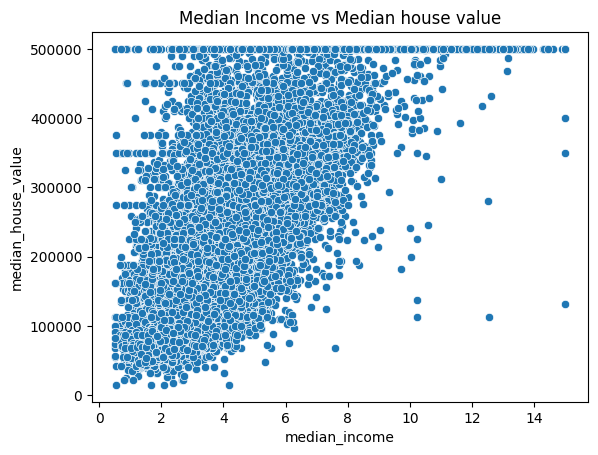

In [11]:
plt.title('Median Income vs Median house value')
sns.scatterplot(x="median_income", y="median_house_value", data=housing)

Interpretation and insights of median house value vs. median income Scatter Plot.

This plots shows good relationship between median house value vs. median income. As income rises the house value rise. The relationship appears to be somewhat linear, indicating that this variable may be a strong predictor in a linear regression model.
Insight of this plot of its clear linear relationship with house prices its good predictor in the linear regression model.




2. Seaborn scatter plot of median house value vs. population

<Axes: title={'center': 'Median Income vs Population'}, xlabel='median_income', ylabel='population'>

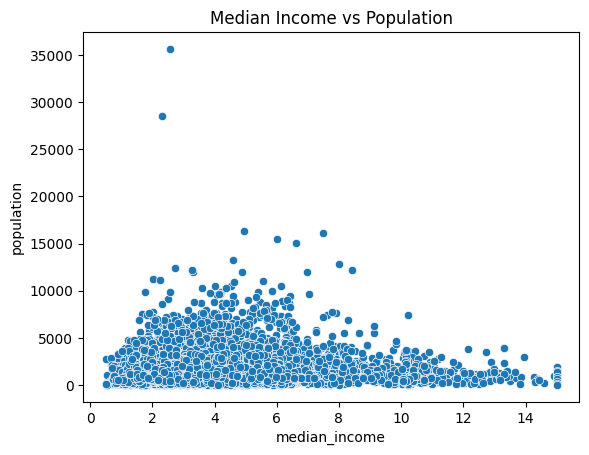

In [12]:
plt.title('Median Income vs Population')
sns.scatterplot(x="median_income", y="population", data=housing)

Interpretation and insights of median house value vs. population Scatter Plot.

The scatter plot shows a \weak and slightly scattered relationship between population and median house prices. While there is a trend of house prices falling as population increases in some areas, the overall trend is unclear. Population may not be so strong in predicting house prices in a univariate model.
Insight of this plot this expected to perform poorly as a predictor due to the lack of a strong, clear trend.

3. Seaborn scatter plot of median house value vs. number of households

<Axes: title={'center': 'Median Income vs Households'}, xlabel='median_income', ylabel='households'>

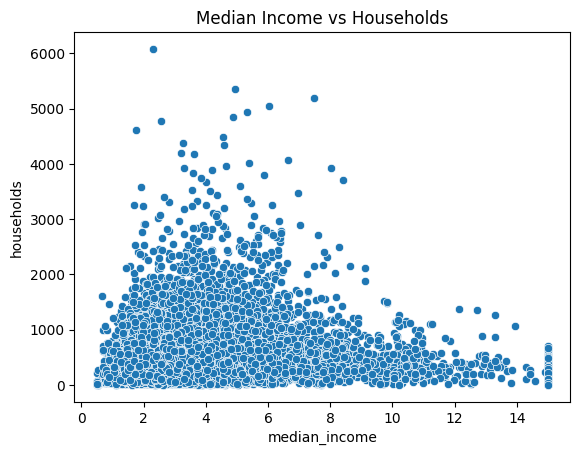

In [13]:
plt.title('Median Income vs Households')
sns.scatterplot(x="median_income", y="households", data=housing)


After filtering, there are 19675 records, versus 20640 before filtering
Intercept: [44618.48413719]
Coefficients: [[ 3.83338815e+04 -3.61490517e+01  1.13816915e+02]]


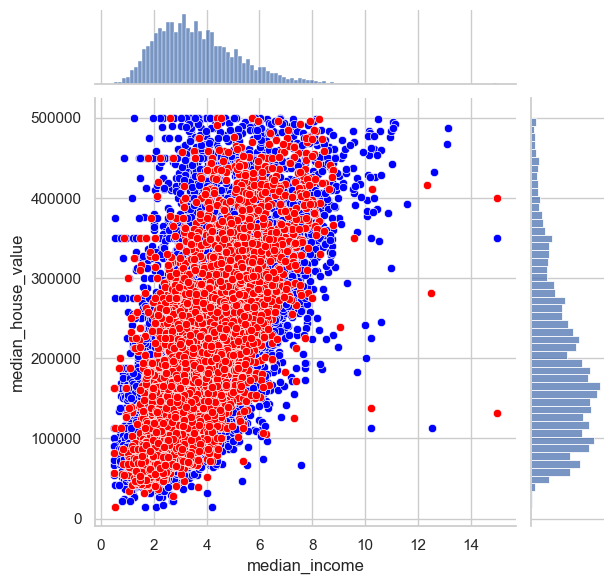

In [24]:
housing_preprocessed = housing[housing.median_house_value != 500001]
print(f"After filtering, there are {len(housing_preprocessed)} records, versus {len(housing)} before filtering")
sns.set(style="whitegrid", color_codes=True)
sns.jointplot(x="median_income", y="median_house_value", data=housing_preprocessed)

train_size = int(len(housing_preprocessed) * 0.8)
train = housing_preprocessed[:train_size]
test = housing_preprocessed[train_size:]

sns.scatterplot(x="median_income", y="median_house_value", data=train, color="blue")
sns.scatterplot(x="median_income", y="median_house_value", data=test, color="red")

model = linear_model.LinearRegression()
model.fit(X=train[["median_income","population","households"]], y=train[["median_house_value"]])
print(f"Intercept: {model.intercept_}")
print(f"Coefficients: {model.coef_}")



Interpretation and insights of median house value vs. household Scatter Plot.

This plot also reveals a slightly positive but weak relationship between the number of homes and median home prices. Like demographics, the trend is not strongly continuous, suggesting that households themselves may not be a significant predictor.
Insight of this plots is similar to population, this variable may not a strong linear relationship, but it may have some predictive value.

 Variables used in this lab:

1. Median Home Price-
   - Definition- Represents the house price in the state of California.
   - Range- Varies widely, with prices typically ranging from $15,000 to over $500,000.
   - Findings - House prices seem to increase in higher income areas. Since values ​​of about \$500,000 often appear, there may be a cap on the dataset.

2. Median income - 
   - Definition- Household income (in tens of thousands of dollars) in the state of California.
   - Range- Usually 0 to 15 (i.e. \$0 to \$150,000).
   - Findings- A clear positive correlation with house prices, indicating higher house prices in wealthier counties.

3. Population- 
   - Definition- The total population of each region.
   - Range- Can vary widely, from less than 100 to more than 30,000.
   - Findings- No negative correlation with house prices. Population density does not necessarily translate into higher or lower housing prices.

4. Household-
   - Definition- Number of households in a region.
   - Range- Usually 50 homes to over 5,000.
   - Findings- Moderate positive relationship between house prices, although not as linear or strong as median income.

In summary, median income shows the strongest relationship with house prices, while population and households exhibit a weaker relationship.

# 4


Run three linear regressions (fitting) between (1.5 point):
median house value vs. median income
median house value vs. population
median house value vs. number of households.

In [15]:
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, mean_absolute_error


def linear_regression(a, b):
    data_model = LinearRegression()
    data_model.fit(a, b)
    prediction = data_model.predict(a)
    mse = mean_squared_error(b, prediction)
    mae = mean_absolute_error(b, prediction)
    return data_model.intercept_, data_model.coef_[0], mse, mae

income = housing[['median_income']]
population = housing[['population']]
households = housing[['households']]
b = housing['median_house_value']

income_result = linear_regression(income, b)
households_result = linear_regression(households, b)
population_result = linear_regression(population, b)

print(income_result)
print(households_result)
print(population_result)
pd.DataFrame()

(np.float64(45085.5767032679), np.float64(41793.849201896286), np.float64(7011311502.929527), np.float64(62625.9337911434))
(np.float64(196928.57716233088), np.float64(19.872775155643875), np.float64(13257776904.728533), np.float64(90802.74324318448))
(np.float64(210436.26207627333), np.float64(-2.511752774615085), np.float64(13307412412.389355), np.float64(91153.82009473183))


""


5. In a single table for all three linear regressions, provide per regression mode.

In [16]:
import pandas as pd
import numpy as np
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, mean_absolute_error

# x 
X_income = housing[['median_income']]
X_population = housing[['population']]
X_households = housing[['households']]

# y 
y = housing['median_house_value']

# Function to run the linear regression and return intercept, slope, MSE, and MAE
def run_regression(X, y):
    model = LinearRegression()
    model.fit(X, y)
    predictions = model.predict(X)
    
    intercept = model.intercept_
    slope = model.coef_[0]
    mse = mean_squared_error(y, predictions)
    mae = mean_absolute_error(y, predictions)
    
    return intercept, slope, mse, mae

# independent variable regression
intercept_income, slope_income, mse_income, mae_income = run_regression(X_income, y)
intercept_population, slope_population, mse_population, mae_population = run_regression(X_population, y)
intercept_households, slope_households, mse_households, mae_households = run_regression(X_households, y)

summary = {
    'Model': ['Median House Value vs Median Income', 
              'Median House Value vs Population', 
              'Median House Value vs Households'],
    'Intercept': [intercept_income, intercept_population, intercept_households],
    'Slope': [slope_income, slope_population, slope_households],
    'MAE': [mae_income, mae_population, mae_households],
    'MSE': [mse_income, mse_population, mse_households]
}

summary_df = pd.DataFrame(summary)

# display table
display(summary_df)

,Model,Intercept,Slope,MAE,MSE
0,Median House Value vs Median Income,45085.576703,41793.849202,62625.933791,7.011312e+09
1,Median House Value vs Population,210436.262076,-2.511753,91153.820095,1.330741e+10
2,Median House Value vs Households,196928.577162,19.872775,90802.743243,1.325778e+10


6. Plot the resulting line on top of the scatter data for each of the three models (three separate graphs), add the line parameters (intercept and slope), MSE and MAE to the graph (you can use a text box). You can use any plotting library for that (Matplotlib, Seaborn or Plotly) 

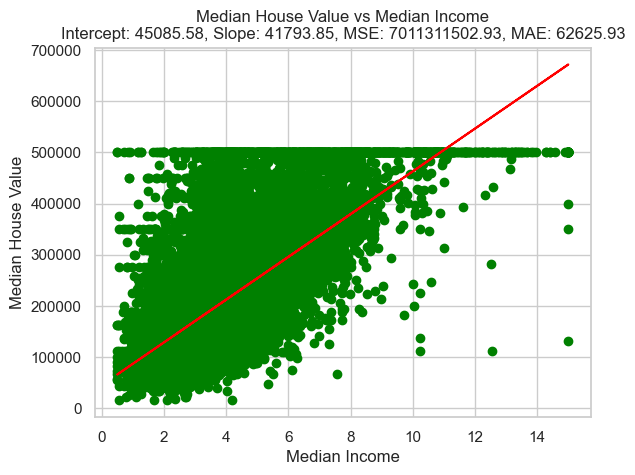

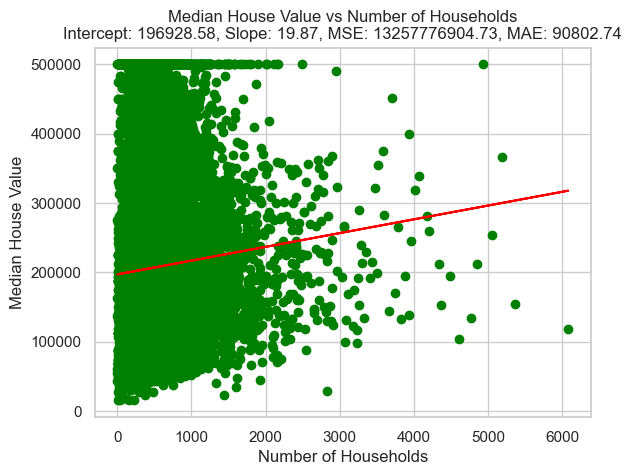

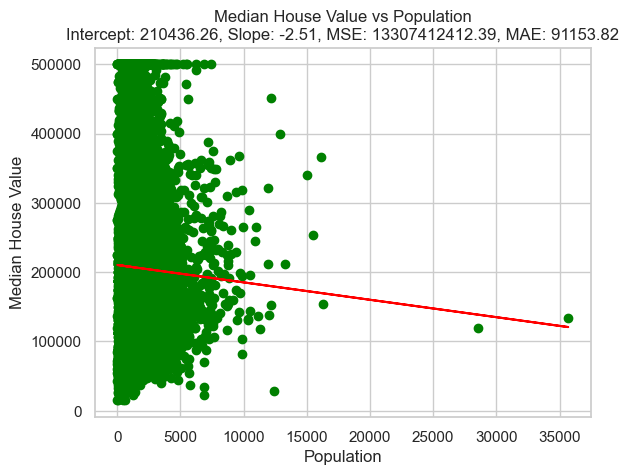

In [17]:
def regression(a, b, intercept, slope, mse, mae, title, xlabel):
    plt.scatter(a, b, color='green')
    plt.plot(a, intercept + slope * a, color='red') 
    plt.title(f'{title}\nIntercept: {intercept:.2f}, Slope: {slope:.2f}, MSE: {mse:.2f}, MAE: {mae:.2f}')
    plt.xlabel(xlabel)
    plt.ylabel('Median House Value')
    plt.show()

    

regression(housing['median_income'], b, income_result[0], income_result[1], income_result[2], income_result[3], 
                     'Median House Value vs Median Income', 'Median Income')

regression(housing['households'], b, households_result[0], households_result[1], households_result[2], households_result[3], 
                     'Median House Value vs Number of Households', 'Number of Households')

regression(housing['population'], b, population_result[0], population_result[1], population_result[2], population_result[3], 
                     'Median House Value vs Population', 'Population')

# Conclusion

Based on above all prediction and analysis we can review,

Median House Value vs. Median Income:
This model demonstrates an excellent fit with minimal errors, clearly illustrating a positive relationship between house values and income.

Number of Households vs. Median House Value:
While this model provides some reasonable predictions, it does exhibit a certain level of error. Overall, it does not perform as well as the income model.

Median House Value vs. Population:
This model shows the weakest correlation, with significantly higher error rates. It suggests that population size does not offer strong predictive power regarding house values

# THANK YOU :)